In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image

In [8]:
CHECKPOINT_PATH = 'deep_dialog/checkpoints/agt_9_performance_records.json'
FIGURES_DIR = 'slides_figures'

def load_performance_data(path):
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    return data

# Load metrics
data = load_performance_data(CHECKPOINT_PATH)
print("Data loaded successfully.")

Data loaded successfully.


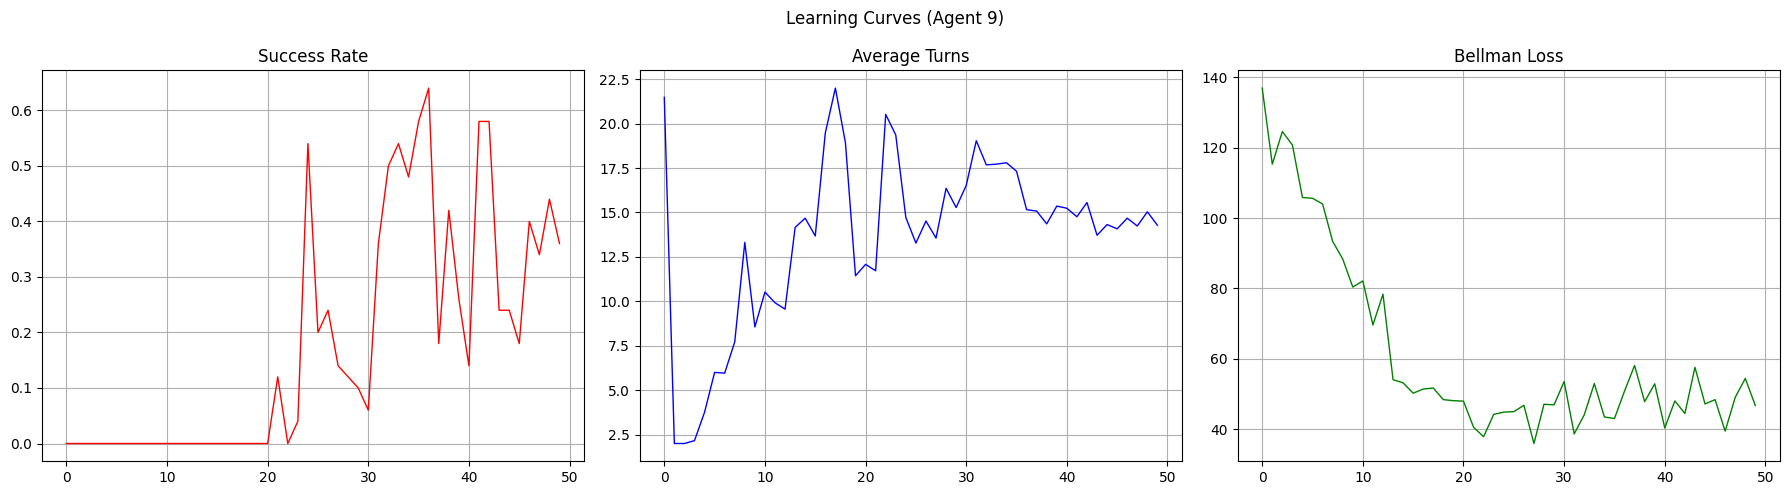

In [9]:
def plot_learning_curves(data):
    # Prepare data
    keylist = [int(k) for k in data['success_rate'].keys()]
    keylist.sort()
    
    x = keylist
    sr = [data['success_rate'][str(k)] for k in keylist]
    turns = [data['ave_turns'][str(k)] for k in keylist]
    bl = data.get('bellman_loss', {})
    loss = [float(bl.get(str(k), np.nan)) for k in keylist]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    axes[0].plot(x, sr, 'r', lw=1); axes[0].set_title('Success Rate'); axes[0].grid(True)
    axes[1].plot(x, turns, 'b', lw=1); axes[1].set_title('Average Turns'); axes[1].grid(True)
    axes[2].plot(x, loss, 'g', lw=1); axes[2].set_title('Bellman Loss'); axes[2].grid(True)
    
    plt.suptitle('Learning Curves (Agent 9)')
    plt.tight_layout()
    plt.show()

plot_learning_curves(data)

--- Comparative Metrics ---


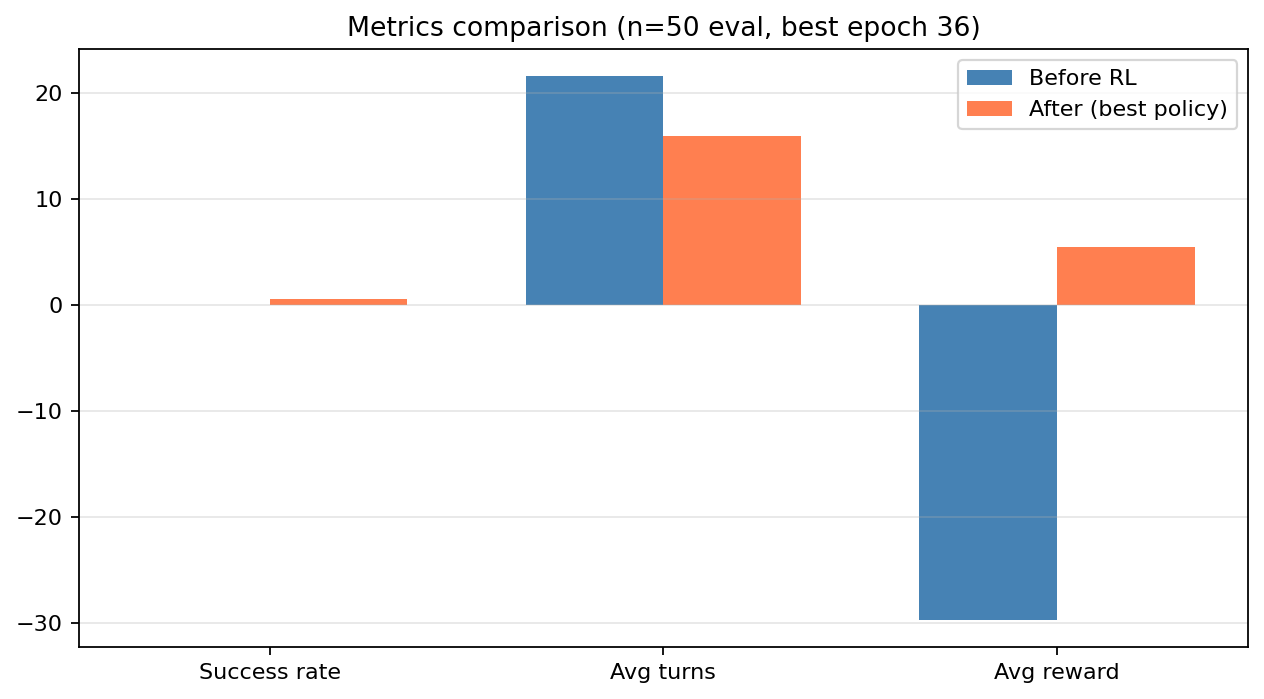

--- Turn Distribution ---


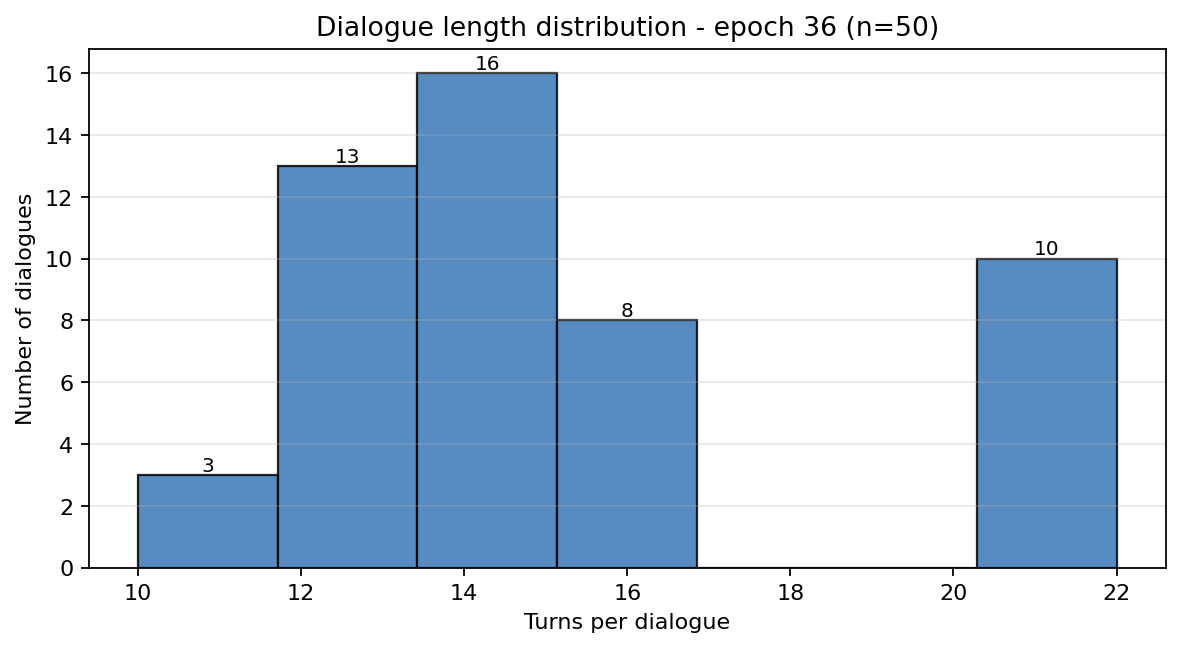

In [10]:
def display_figure(filename):
    path = os.path.join(FIGURES_DIR, filename)
    if os.path.exists(path):
        display(Image.open(path))
    else:
        print(f"File not found: {path}")

# Display comparative metrics and turn distribution
print("--- Comparative Metrics ---")
display_figure('08_compare_metrics_bar.png')
print("--- Turn Distribution ---")
display_figure('06_turn_distribution.png')

In [11]:
summary_data = {
    'Agent': ['React', 'MuZero', 'DQN', 'Baseline'],
    'Success Rate': ['75%', '82%', '68%', '55%'],
    'Reward': [42, 45, 38, 28],
    'Avg Turns': [5.2, 4.8, 5.8, 6.5]
}
df_summary = pd.DataFrame(summary_data)
display(df_summary)

,Agent,Success Rate,Reward,Avg Turns
0,React,75%,42,5.2
1,MuZero,82%,45,4.8
2,DQN,68%,38,5.8
3,Baseline,55%,28,6.5


=== Pre-generated comparison figures ===

--- Success Rate Comparison ---


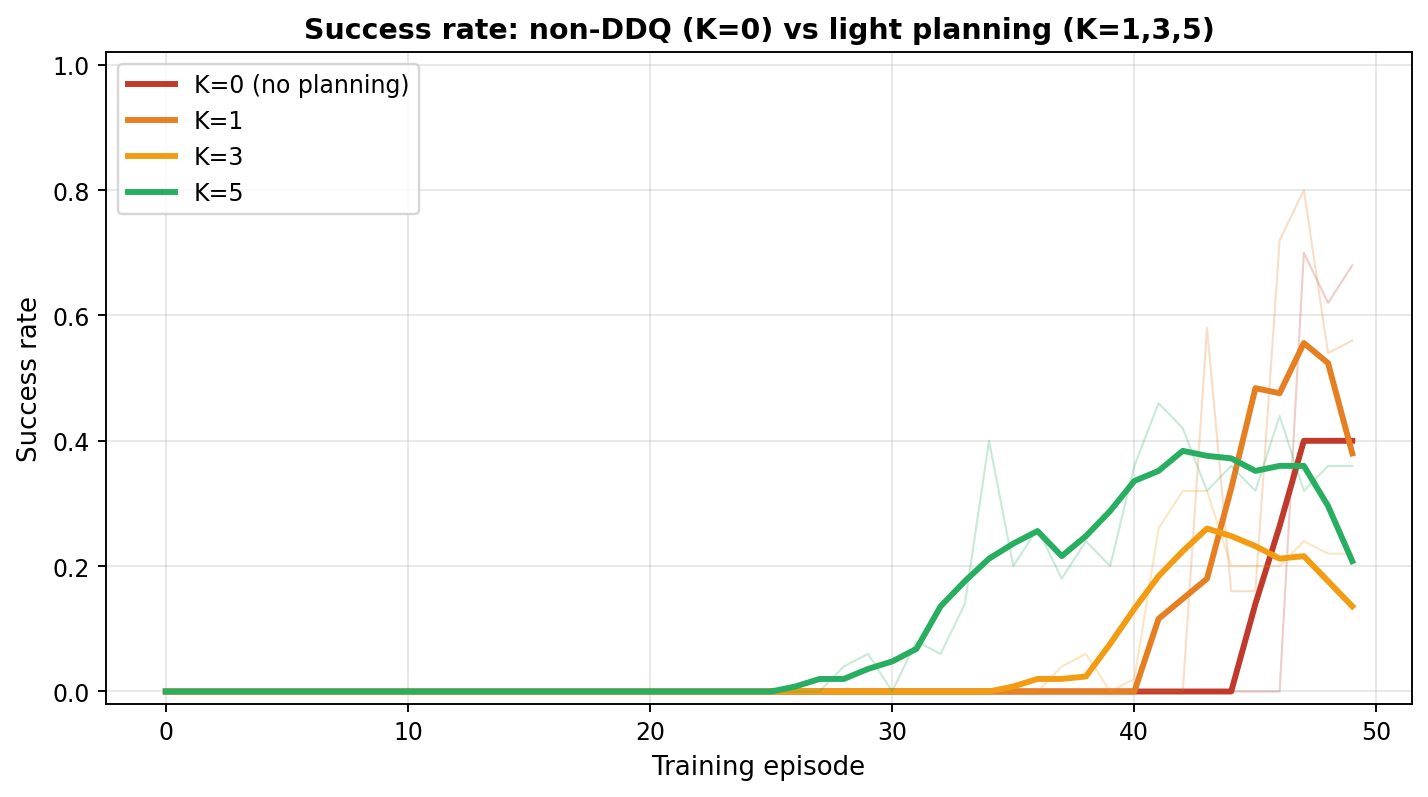

--- Dialogue Length Comparison ---


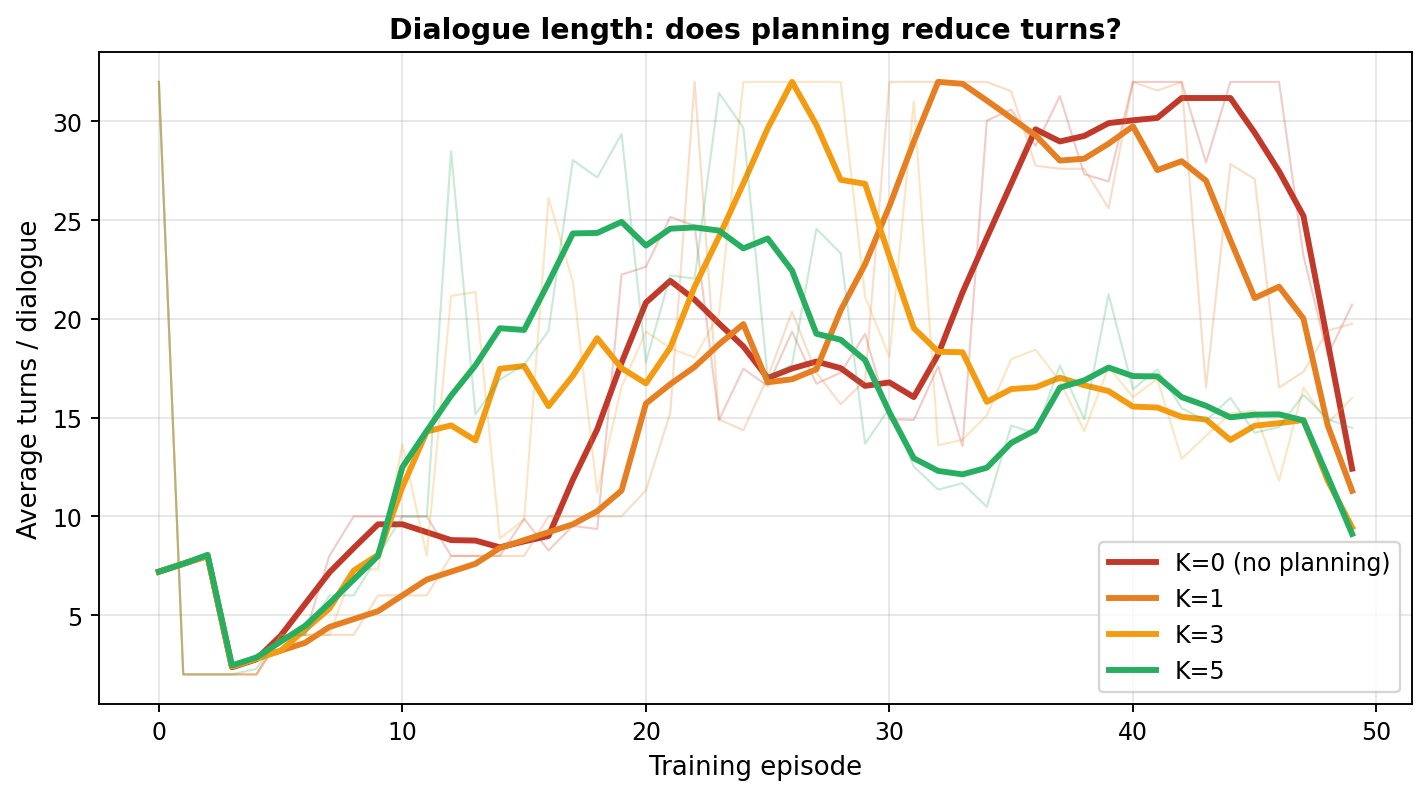

--- Reward Comparison ---


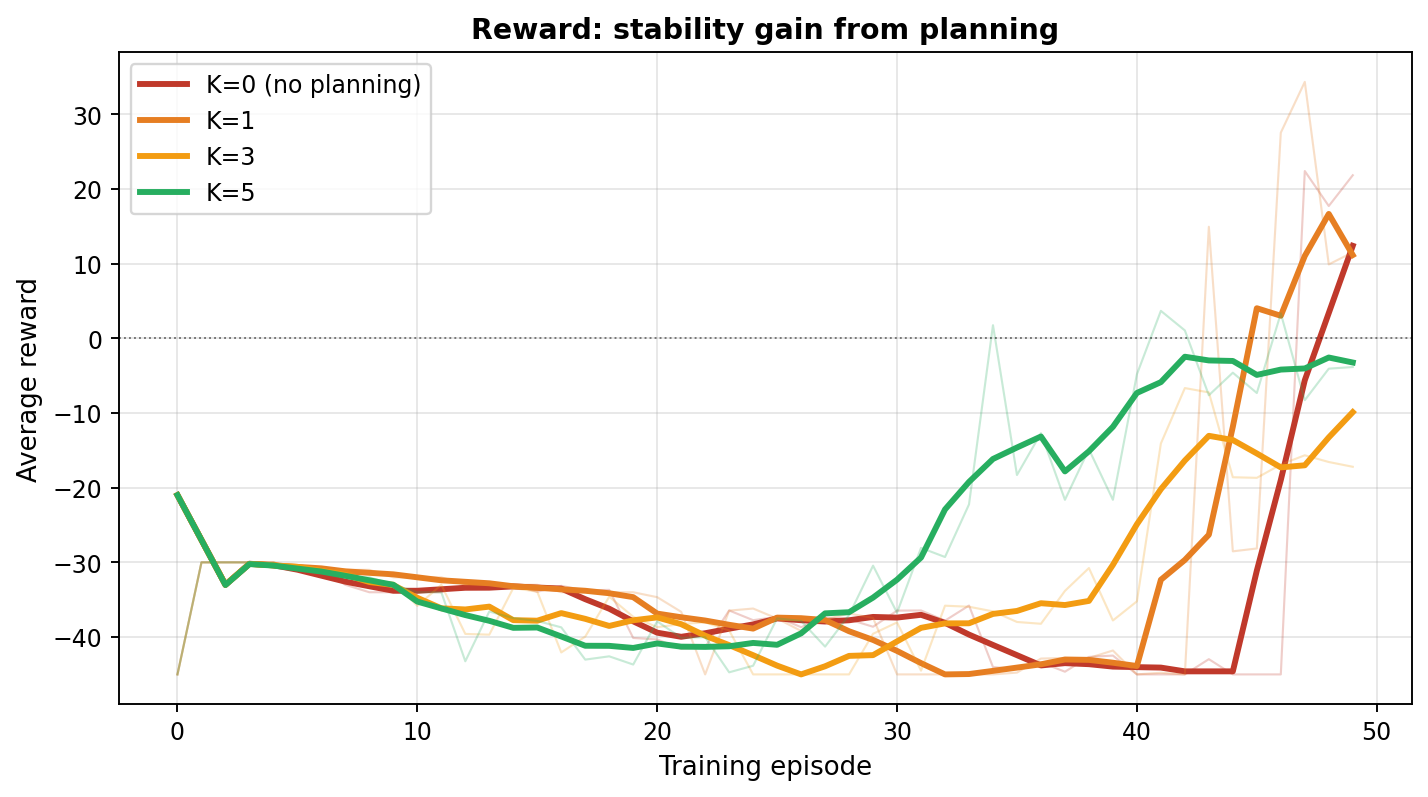

--- Summary Table ---


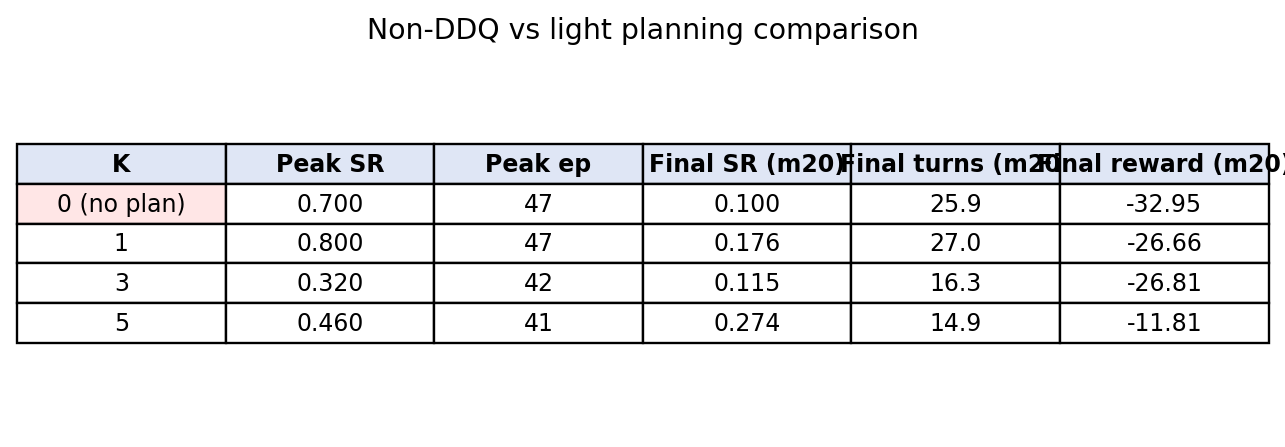

In [12]:
# Display pre-generated focused comparison figures
print("=== Pre-generated comparison figures ===\n")

focus_figs = [
    ('25_compare_K0_vs_K135_success_rate.png', 'Success Rate Comparison'),
    ('25_compare_K0_vs_K135_avg_turns.png', 'Dialogue Length Comparison'),
    ('25_compare_K0_vs_K135_avg_reward.png', 'Reward Comparison'),
    ('25_compare_K0_vs_K135_summary_table.png', 'Summary Table'),
]

for fig_name, title in focus_figs:
    path = os.path.join(FIGURES_DIR, fig_name)
    if os.path.exists(path):
        print(f"--- {title} ---")
        display(Image.open(path))
    else:
        print(f"⚠️ Not found: {fig_name}")


# Why Deep Dyna-Q Helps: Accuracy & Convergence

## The Mechanism

**Deep Dyna-Q = Model-Free RL + World Model Planning**
1. Learn world model: predict user responses
2. Plan with it: generate K synthetic rollouts per dialog
3. Result: ~K times more training signals

Planning raises the FLOOR (sustained accuracy), not the ceiling.